In [4]:
import pandas as pd

path = "../data/test/_classes.csv"
df = pd.read_csv(path)
df.head()

,Unnamed: 0,filename,lable
0,0,augmented_image_296_jpg.rf.02ea4d8b506c3602ce7...,without_mask
1,1,452_jpg.rf.046515080b31ae5e8d248fb3e1a494b4.jpg,without_mask
2,2,augmented_image_155_jpg.rf.0537542ea3e55b86f6d...,with_mask
3,3,123-with-mask_jpg.rf.07ed131627d28008bd41871f1...,with_mask
4,4,augmented_image_115_jpg.rf.09fd45f64e5886f0ae7...,with_mask


In [2]:
def helper(df: pd.DataFrame):
    df["label"] = df.apply(
        lambda row: "with_mask" if row["with_mask"] == 1 else "without_mask",
        axis=1
    )
    return df

In [ ]:
# df["lable"] = df[[" with_mask", " without_mask"]].idxmax(axis=1)

KeyError: "None of [Index([' with_mask', ' without_mask'], dtype='object')] are in the [columns]"

In [ ]:
df = df[['filename','lable']]

In [ ]:
# df.to_csv(path,index=False)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory="../data/test",
    x_col="filename",
    y_col="lable",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)


Found 127 validated image filenames belonging to 2 classes.


In [15]:
print(train_generator.class_indices)
print(train_generator.samples)
print(train_generator.batch_size)


{' with_mask': 0, ' without_mask': 1}
127
32


In [17]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)


(32, 224, 224, 3)
(32, 2)


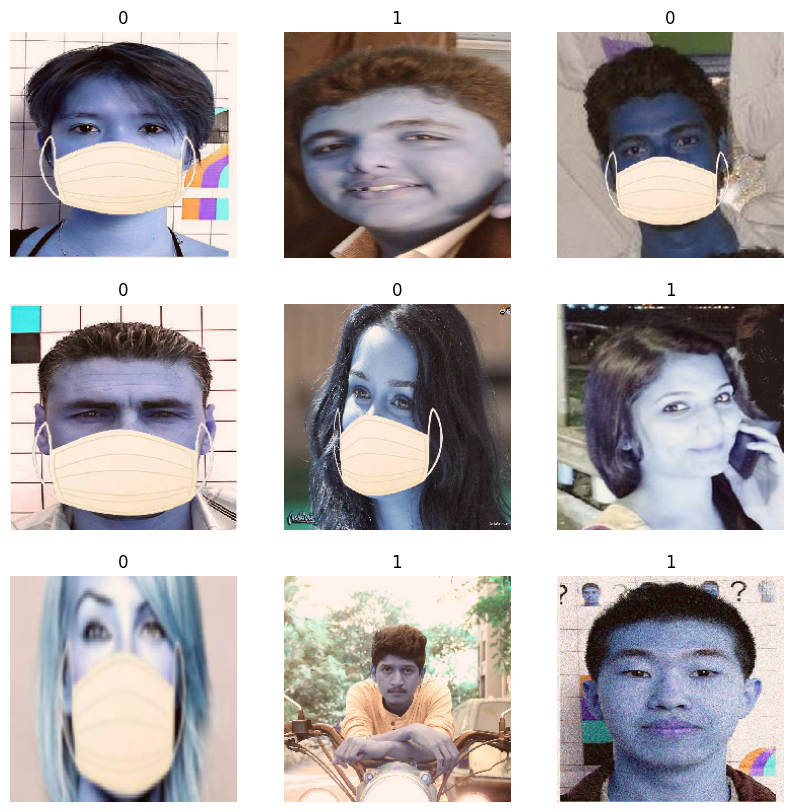

In [18]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    
    # VGG16 preprocess changes pixel range, so reverse it for display
    img = images[i]
    img = img - img.min()
    img = img / img.max()
    
    plt.imshow(img)
    plt.title(np.argmax(labels[i]))
    plt.axis("off")

plt.show()
